In [1]:
import os
import random

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize

from core.data import load_dataset, split_dataset, BreathDataset, CLASSES, CLASS_TO_IDX
from models.pinn import BreathMLP

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

In [2]:
# params
REGION = ['mouth', 'nose']
SEED = 42
T_MAX = 70.0
N_TIMESTEPS = 36
CKPT = {region:f'results/mlp/{region}_s{SEED}' for region in REGION}
CHANNEL_NAMES = ['Humidity (norm.)', 'Temperature (norm.)']

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

train: 215 val: 28 test: 28
Loaded 215 models from results/mlp/mouth_s42
Mean MSE Summary:
Combined (H+T)	: 0.00099
Humidity	: 0.00101
Temperature	: 0.00097
bradypnea   	: 0.00207 (n=71)
eupnea      	: 0.00054 (n=68)
tachypnea   	: 0.00039 (n=76)
Stage 1 reconstruction: 215/215 samples pass threshold (MSE < 1.0)


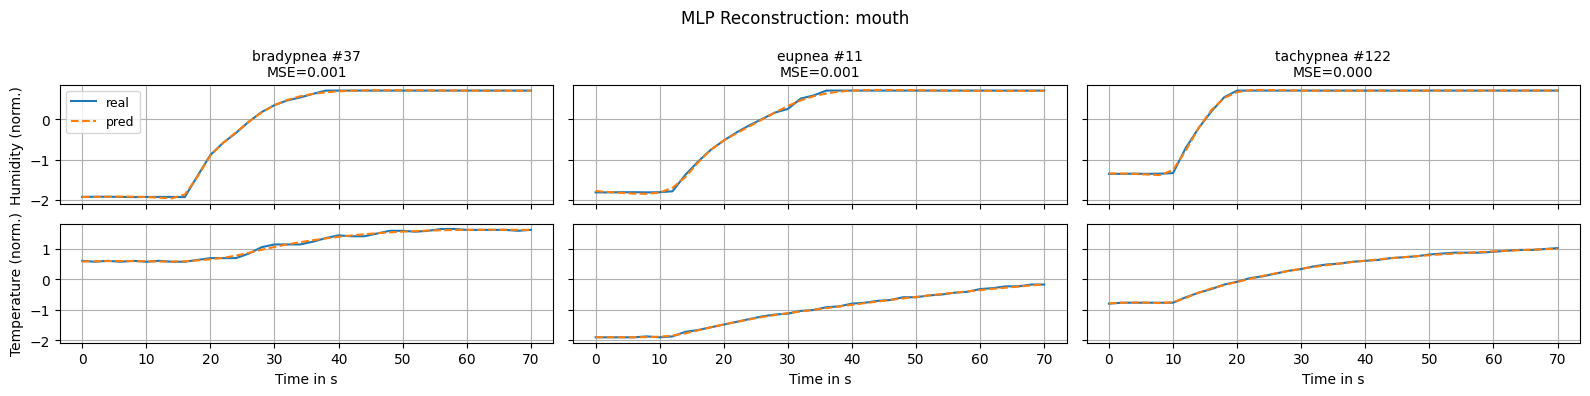

train: 298 val: 38 test: 38
Loaded 298 models from results/mlp/nose_s42
Mean MSE Summary:
Combined (H+T)	: 0.00127
Humidity	: 0.00199
Temperature	: 0.00054
bradypnea   	: 0.00255 (n=103)
eupnea      	: 0.00063 (n=98)
tachypnea   	: 0.00056 (n=97)
Stage 1 reconstruction: 298/298 samples pass threshold (MSE < 1.0)


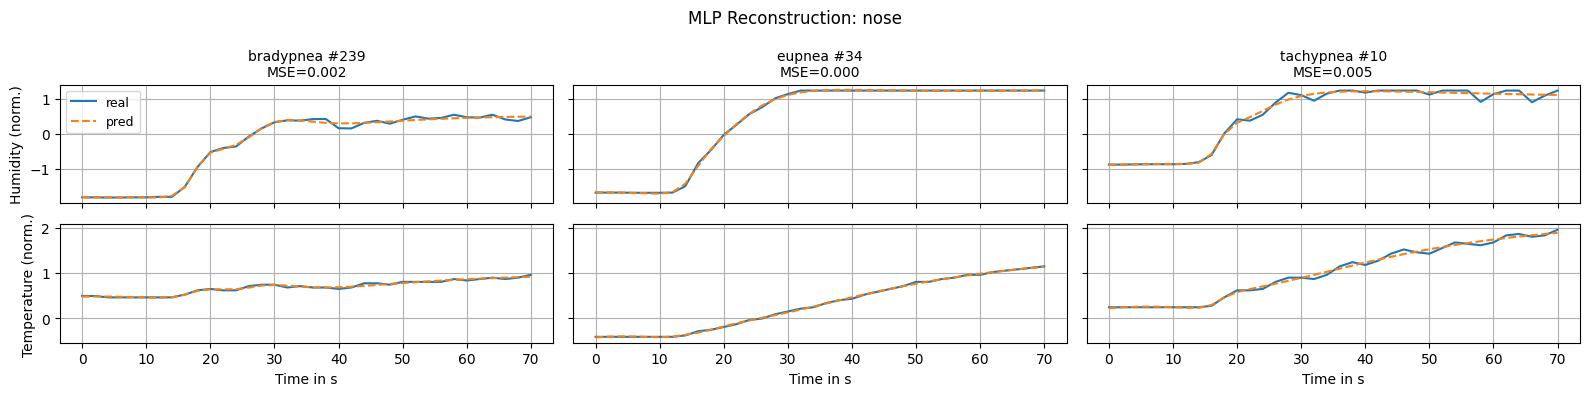

In [3]:
# step 1: mlp reconstruction
for region in REGION:
    # load data
    df = load_dataset('dataset')
    df = df[df['region'] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=SEED)
    train_ds = BreathDataset(df_train)
    val_ds   = BreathDataset(df_val, stats=train_ds.stats)
    test_ds  = BreathDataset(df_test, stats=train_ds.stats)

    t_norm = torch.linspace(0, T_MAX, N_TIMESTEPS) / T_MAX

    print(f'train: {len(train_ds)} val: {len(val_ds)} test: {len(test_ds)}')

    # load models
    fitted: list[tuple[BreathMLP, int, int]] = []

    for i in range(len(train_ds)):
        ckpt = os.path.join(CKPT[region], f'sample_{i}.pt')
        _, _, label, _ = train_ds[i]
        model = BreathMLP()
        model.load_state_dict(torch.load(ckpt, map_location='cpu', weights_only=True))
        model.eval()
        fitted.append((model, label, i))
    print(f'Loaded {len(fitted)} models from {CKPT[region]}')

    # summary
    hum_mse, tmp_mse, comb_mse = [], [], []
    per_class: dict[str, list[float]] = {cls: [] for cls in CLASSES}

    for model, label, sample_i in fitted:
        signal, _, _, _ = train_ds[sample_i]
        with torch.no_grad():
            y_pred = model(t_norm, label)
        y_obs = signal.T
        h = nn.functional.mse_loss(y_pred[:, 0], y_obs[:, 0]).item()
        t = nn.functional.mse_loss(y_pred[:, 1], y_obs[:, 1]).item()
        c = nn.functional.mse_loss(y_pred, y_obs).item()
        hum_mse.append(h)
        tmp_mse.append(t)
        comb_mse.append(c)
        per_class[CLASSES[label]].append(c)

    comb_mse = np.array(comb_mse)

    print(f'{'Mean MSE Summary:'}')
    print(f'Combined (H+T)\t: {np.mean(comb_mse):.5f}')
    print(f'Humidity\t: {np.mean(hum_mse):.5f}')
    print(f'Temperature\t: {np.mean(tmp_mse):.5f}')
    for cls in CLASSES:
        vals = per_class[cls]
        print(f'{cls:<12}\t: {np.mean(vals):.5f} (n={len(vals)})')

    n_pass = int((comb_mse < 1.0).sum())
    N = len(comb_mse)
    print(f'Stage 1 reconstruction: {n_pass}/{N} samples pass threshold (MSE < 1.0)')

    # plot
    rng = random.Random(SEED)
    selected_samples: list = []
    selected_models:  list = []

    for cls in CLASSES:
        cls_idx = CLASS_TO_IDX[cls]
        pool = [i for i, (_, lbl, _) in enumerate(fitted) if lbl == cls_idx]

        if not pool:
            continue
        fi = rng.choice(pool)
        model, lbl, sample_i = fitted[fi]
        signal, _, _, _ = train_ds[sample_i]

        selected_samples.append((signal, lbl, sample_i))
        selected_models.append(model)

    t_plot = torch.linspace(0, T_MAX, N_TIMESTEPS).numpy()

    fig, axes = plt.subplots(2, 3, figsize=(16, 4), sharex=True, sharey='row')
    fig.suptitle(f'MLP Reconstruction: {region}')

    for col, ((signal, label, idx), model) in enumerate(zip(selected_samples[:3], selected_models[:3])):
        with torch.no_grad():
            y_pred = model(t_norm, label).numpy()

        y_obs = signal.T.numpy()
        mse_row = float(np.mean((y_pred - y_obs) ** 2))

        for ch in range(2):
            ax = axes[ch, col]
            ax.plot(t_plot, y_obs[:, ch], '-', color='tab:blue', lw=1.5, label='real')
            ax.plot(t_plot, y_pred[:, ch], '--', color='tab:orange', lw=1.5, label='pred')
            ax.grid()
            if ch == 0:
                ax.set_title(f'{CLASSES[label]} #{idx}\nMSE={mse_row:.3f}')
            if col == 0:
                ax.set_ylabel(CHANNEL_NAMES[ch])
            if ch == 1:
                ax.set_xlabel('Time in s')
            ax.tick_params()
            if ch == 0 and col == 0:
                ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

In [4]:
# step 2: physics modeling
region = 'mouth'

# load data
df = load_dataset('dataset')
df = df[df['region'] == region].reset_index(drop=True)
df_train, df_val, df_test = split_dataset(df, random_state=SEED)

# get one sample
signal = df_train.iloc[0]

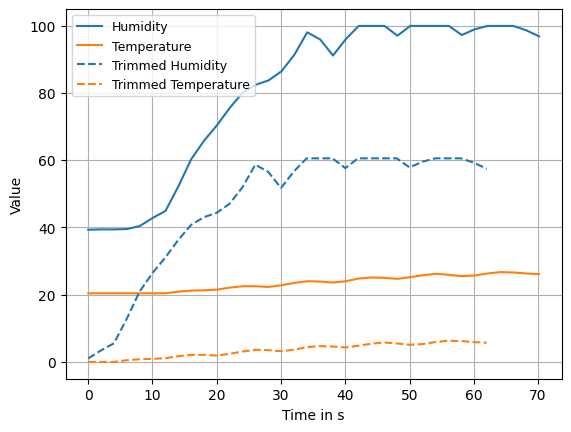

In [5]:
def preprocess_signals(sample):
    channel_h = sample['humidity'].copy()
    channel_t = sample['temperature'].copy()

    # estimate baseline
    baseline_h = channel_h[:3]
    baseline_t = channel_t[:3] 

    # get signal stats
    baseline_mean_h = np.mean(baseline_h)
    baseline_std_h = np.std(baseline_h, ddof=1)
    baseline_mean_t = np.mean(baseline_t)

    # 3-sigma rule for onset
    threshold_h = baseline_mean_h + 3.0 * baseline_std_h

    # find index where both ch exceed threshold
    for onset_idx in range(channel_h.shape[0] - 1):
        if channel_h[onset_idx] > threshold_h:
            break
    
    # baseline correct amplitude
    channel_h -= baseline_mean_h
    channel_t -= baseline_mean_t

    # trim to onset
    trimmed_signal = np.stack([channel_h[onset_idx:], channel_t[onset_idx:]],axis=0)
    trimmed_len = trimmed_signal.shape[1]
    trimmed_time = np.linspace(0.0, (trimmed_len - 1) * 2.0, trimmed_len)

    return trimmed_time, trimmed_signal

trimmed_time, trimmed_signal = preprocess_signals(signal)

plt.figure()
plt.plot(signal['time'], signal['humidity'], color='tab:blue', label='Humidity')
plt.plot(signal['time'], signal['temperature'], color='tab:orange', label='Temperature')
plt.plot(trimmed_time, trimmed_signal[0], '--', color='tab:blue', label='Trimmed Humidity')
plt.plot(trimmed_time, trimmed_signal[1], '--', color='tab:orange', label='Trimmed Temperature')
plt.xlabel('Time in s')
plt.ylabel('Value')
plt.grid()
plt.legend(loc='upper left')
plt.show()

alpha_H=0.0606, c_H=3.8781 -> y_ss_H=64.0
alpha_T=0.0094, c_T=0.1363 -> y_ss_T=14.6


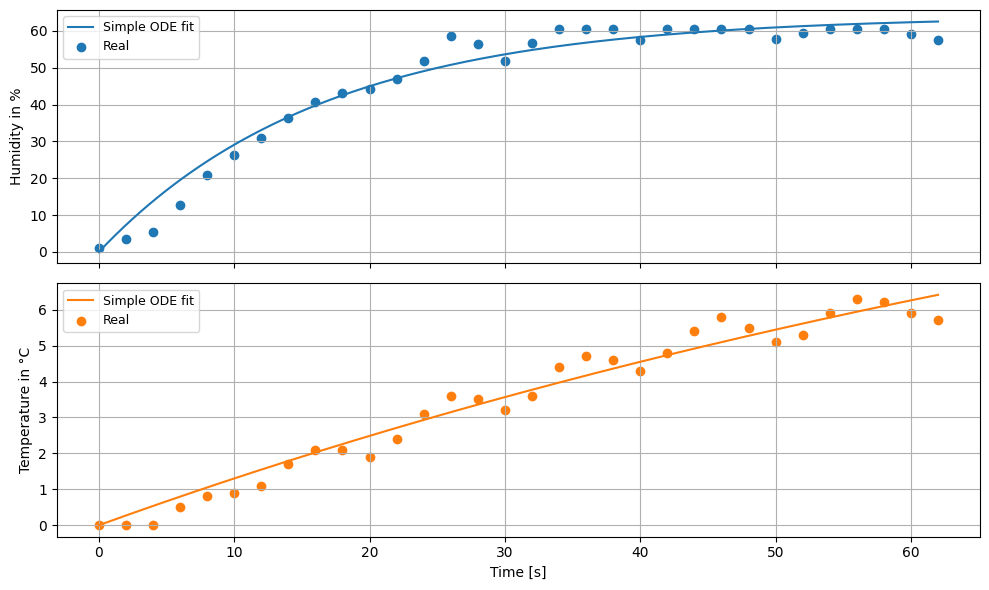

In [6]:
def ode_rhs(y, t, alpha_H, c_H, alpha_T, c_T):
    y_H, y_T = y
    dy_H = -alpha_H * y_H + c_H
    dy_T = -alpha_T * y_T + c_T
    return [dy_H, dy_T]

def objective(params, trimmed_time, trimmed_signal):
    alpha_H, c_H, alpha_T, c_T = params
    sol = odeint(ode_rhs, [0.0, 0.0], trimmed_time, args=(alpha_H, c_H, alpha_T, c_T))
    mse_H = np.mean((sol[:, 0] - trimmed_signal[0]) ** 2)
    mse_T = np.mean((sol[:, 1] - trimmed_signal[1]) ** 2)
    return (1/55**2) * mse_H + (1/5**2) * mse_T

# params: alpha_H, c_H, alpha_T, c_T
x0 = [0.1, 5.0, 0.05, 0.1]
bounds = [(1e-4, 5.0), (1e-4, 100.0), (1e-4, 5.0), (1e-4, 10.0)]

# optimize parameters
result = minimize(objective, x0, method='L-BFGS-B', bounds=bounds, args=(trimmed_time, trimmed_signal))
alpha_H, c_H, alpha_T, c_T = result.x

# fit ode
t_dense = np.linspace(0, trimmed_time[-1], 300)
sol_simple = odeint(ode_rhs, [0.0, 0.0], t_dense, args=(alpha_H, c_H, alpha_T, c_T)) 

# summary
print(f'alpha_H={alpha_H:.4f}, c_H={c_H:.4f} -> y_ss_H={c_H/alpha_H:.1f}')
print(f'alpha_T={alpha_T:.4f}, c_T={c_T:.4f} -> y_ss_T={c_T/alpha_T:.1f}')

# plot
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(t_dense, sol_simple[:, 0], label='Simple ODE fit', color='tab:blue')
ax[0].scatter(trimmed_time, trimmed_signal[0], label='Real', color='tab:blue')
ax[0].set_ylabel('Humidity in %')
ax[0].legend()
ax[0].grid()

ax[1].plot(t_dense, sol_simple[:, 1], label='Simple ODE fit', color='tab:orange')
ax[1].scatter(trimmed_time, trimmed_signal[1], label='Real', color='tab:orange')
ax[1].set_ylabel('Temperature in °C')
ax[1].legend()
ax[1].grid()

plt.xlabel('Time [s]')
plt.tight_layout()
plt.show()

In [9]:
# step 3: fit ODE across all samples (both regions)
import os
import pandas as pd
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kw):
        return iterable

os.makedirs('results/ode_fit', exist_ok=True)

df_all = load_dataset('dataset')
print(f"Total samples: {len(df_all)}  {df_all['region'].value_counts().to_dict()}")

records = []
for idx, sample in tqdm(df_all.iterrows(), total=len(df_all), desc='Fitting ODE'):
    try:
        trimmed_time, trimmed_signal = preprocess_signals(sample)
        result = minimize(
            objective,
            x0,
            method='L-BFGS-B',
            bounds=bounds,
            args=(trimmed_time, trimmed_signal),
        )
        alpha_H, c_H, alpha_T, c_T = result.x
        records.append({
            'label':       sample['class'],
            'region':      sample['region'],
            'participant': sample['participant'],
            'trial_num':   sample['trial_num'],
            'alpha_H':  alpha_H,
            'c_H':      c_H,
            'alpha_T':  alpha_T,
            'c_T':      c_T,
            'y_ss_H':   c_H / alpha_H,
            'y_ss_T':   c_T / alpha_T,
            'converged': result.success,
        })
    except Exception as e:
        print(f"Sample {idx} ({sample['class']}/{sample['region']}) failed: {e}")
        records.append({
            'label':       sample['class'],
            'region':      sample['region'],
            'participant': sample['participant'],
            'trial_num':   sample['trial_num'],
            'alpha_H': np.nan, 'c_H': np.nan,
            'alpha_T': np.nan, 'c_T': np.nan,
            'y_ss_H':  np.nan, 'y_ss_T': np.nan,
            'converged': False,
        })

df_params = pd.DataFrame(records)
df_params.to_csv('results/ode_fit/ode_params_all.csv', index=False)
print(f"\nSaved {len(df_params)} records → results/ode_fit/ode_params_all.csv")

n_failed = (~df_params['converged']).sum()
print(f"Failed to converge: {n_failed}/{len(df_params)}\n")

print("Mean ± Std by (region, label):")
for (region, label), grp in df_params.groupby(['region', 'label']):
    conv = grp[grp['converged']]
    print(f"\n  {region}/{label}  (n={len(grp)}, converged={len(conv)})")
    for col in ['alpha_H', 'c_H', 'y_ss_H', 'alpha_T', 'c_T', 'y_ss_T']:
        print(f"    {col:10s}: {conv[col].mean():.4f} ± {conv[col].std():.4f}")


Total samples: 645  {'nose': 374, 'mouth': 271}


Fitting ODE:   0%|          | 0/645 [00:00<?, ?it/s]


Saved 645 records → results/ode_fit/ode_params_all.csv
Failed to converge: 0/645

Mean ± Std by (region, label):

  mouth/bradypnea  (n=89, converged=89)
    alpha_H   : 0.1180 ± 0.0667
    c_H       : 6.4335 ± 2.7816
    y_ss_H    : 57.7906 ± 7.5525
    alpha_T   : 0.0842 ± 0.5281
    c_T       : 0.2166 ± 0.7948
    y_ss_T    : 14.9193 ± 63.5814

  mouth/eupnea  (n=86, converged=86)
    alpha_H   : 0.1393 ± 0.0723
    c_H       : 7.3788 ± 3.5808
    y_ss_H    : 54.8893 ± 8.6722
    alpha_T   : 0.0324 ± 0.0150
    c_T       : 0.2060 ± 0.0633
    y_ss_T    : 14.3361 ± 66.5709

  mouth/tachypnea  (n=96, converged=96)
    alpha_H   : 0.1213 ± 0.0632
    c_H       : 6.4796 ± 2.7468
    y_ss_H    : 56.3488 ± 8.5262
    alpha_T   : 0.0394 ± 0.0232
    c_T       : 0.2214 ± 0.0928
    y_ss_T    : 6.2985 ± 2.3028

  nose/bradypnea  (n=129, converged=129)
    alpha_H   : 0.0896 ± 0.0420
    c_H       : 4.4366 ± 2.1356
    y_ss_H    : 49.8809 ± 6.7254
    alpha_T   : 0.0104 ± 0.0128
    c_T     

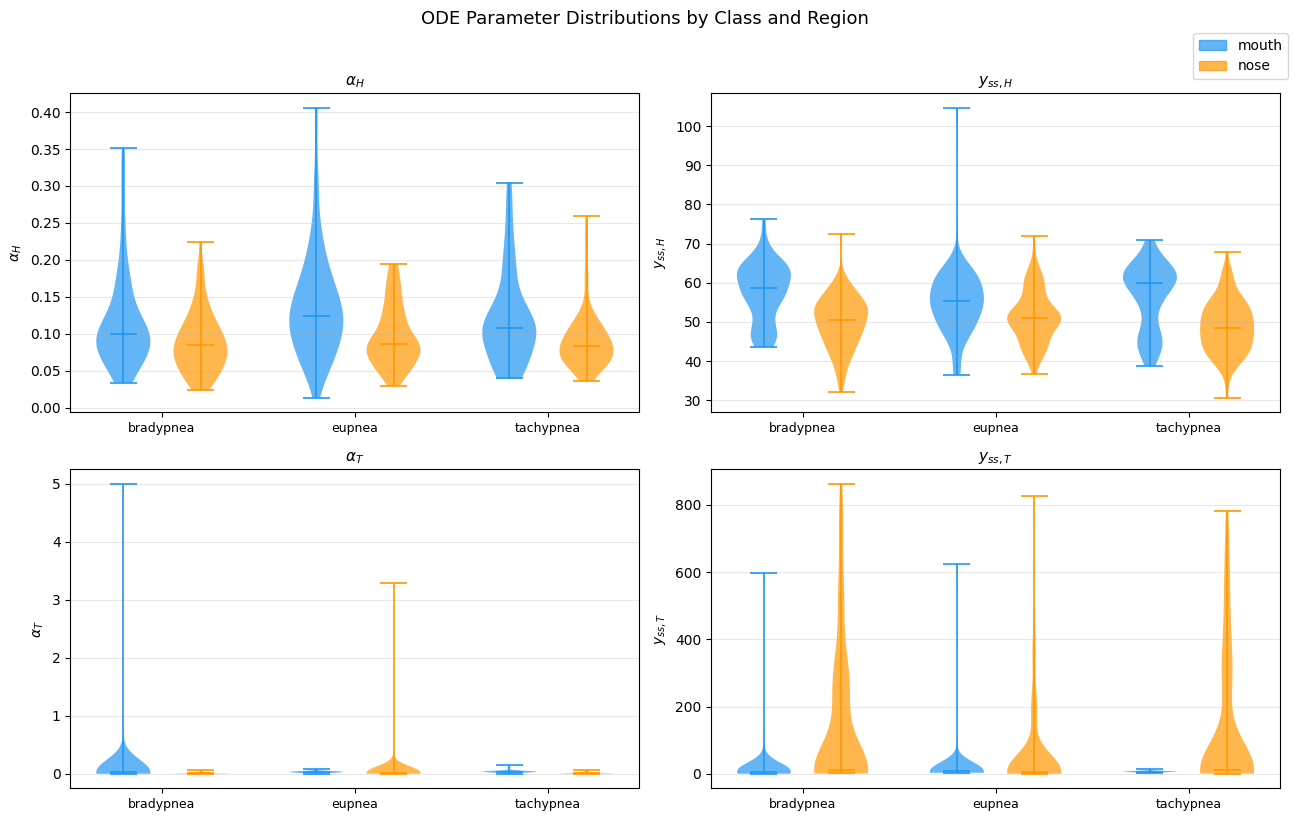

Saved → results/ode_fit/param_distributions.{pdf,png}


In [8]:
# step 4: parameter distribution plots
import matplotlib.patches as mpatches

params_to_plot = ['alpha_H', 'y_ss_H', 'alpha_T', 'y_ss_T']
param_labels   = [r'$\alpha_H$', r'$y_{ss,H}$', r'$\alpha_T$', r'$y_{ss,T}$']
class_order    = ['bradypnea', 'eupnea', 'tachypnea']
regions        = ['mouth', 'nose']
colors         = {'mouth': '#2196F3', 'nose': '#FF9800'}

df_conv = df_params[df_params['converged']].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, param, plabel in zip(axes, params_to_plot, param_labels):
    x_pos = 0
    xtick_pos, xtick_labels = [], []

    for cls in class_order:
        cls_center = x_pos + 0.5
        for region in regions:
            mask = (df_conv['label'] == cls) & (df_conv['region'] == region)
            vals = df_conv.loc[mask, param].dropna().values
            if len(vals) > 0:
                vp = ax.violinplot([vals], positions=[x_pos], widths=0.7, showmedians=True)
                for body in vp['bodies']:
                    body.set_facecolor(colors[region])
                    body.set_alpha(0.7)
                for part in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
                    vp[part].set_color(colors[region])
                    vp[part].set_linewidth(1.2)
            x_pos += 1

        xtick_pos.append(cls_center)
        xtick_labels.append(cls)
        x_pos += 0.5  # gap between classes

    ax.set_xticks(xtick_pos)
    ax.set_xticklabels(xtick_labels, fontsize=9)
    ax.set_ylabel(plabel, fontsize=10)
    ax.set_title(plabel, fontsize=11)
    ax.grid(axis='y', alpha=0.3)

patches = [mpatches.Patch(color=colors[r], label=r, alpha=0.7) for r in regions]
fig.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=10)
fig.suptitle('ODE Parameter Distributions by Class and Region', fontsize=13, y=1.02)

plt.tight_layout()
os.makedirs('results/ode_fit', exist_ok=True)
plt.savefig('results/ode_fit/param_distributions.pdf', bbox_inches='tight')
plt.savefig('results/ode_fit/param_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → results/ode_fit/param_distributions.{pdf,png}")